# Filter midap trackID data

In this notebook, we will present the standard method of trackID data filtering

The filtering will work as follows:

for each cell / trackID, we:
- ensure that we have at least N data points
- ensure that the size measurement value never increases/decreases more than X % between two adjacent frames

If any of these assumptions are violated, the entire trackID with all its data will be removed from the analysis


We first start by loading the example data from the guide. You can replace this path with a path of your experiment

In [1]:

from fluid_experiment.fluid_experiment import FluidExperiment
PATH = "../../data/midap-tools_example"
experiment = FluidExperiment(PATH)

Loading sample at position pos1 for color channel YFP
Loading sample at position pos1 for color channel CFP
Loading sample at position pos2 for color channel YFP
Loading sample at position pos2 for color channel CFP
Loading sample at position pos3 for color channel YFP
Loading sample at position pos3 for color channel CFP
Loading sample at position pos4 for color channel YFP
Loading sample at position pos4 for color channel CFP
Loading sample at position pos5 for color channel YFP
Loading sample at position pos5 for color channel CFP
Loading sample at position pos6 for color channel YFP
Loading sample at position pos6 for color channel CFP
Successfully loaded data with consistent number of frames: 143


## Setting parameters

Set the parameters below for filtering. These you will have to optimize for your own usecase

- `size_column`: what is the name of the column which you use to measure size? (usually `"area"` or `"major_axis_length"`)
- `id_column`: what is the name of the column which describes the cell ID? (usually `"trackID"`)
- `cutoff_percentage_increase` / `cutoff_percentage_decrease`: what is the maximum percentage that a cell can change at a single frame (grow or receeding) before being filtered out completely
- `min_occurences`: how many data points does a cell need at least? otherwise it will be removed

In [2]:
size_column = "major_axis_length"
id_column = "trackID"
cutoff_percentage_increase = 20
cutoff_percentage_decrease = 20
min_occurences = 5


## Script to apply filter to entire experiment

now, run the entire following script

it will:
- log transform your measurement variable
- calculate the rate at which this variable changes between any two frames (within your cells)
- filter out entire cells if they either have to little data, or a cell has to strong increases / decreases
- create a filter report that tells you how many unique values and data rows were filtered and by what method

In [3]:

#we first log transform our percentage. alternatively, you can directly work with logarithmic cutoffs
import math
cutoff_log_increase = math.log((100 + cutoff_percentage_increase) / 100)
cutoff_log_decrease = -math.log((100 + cutoff_percentage_increase) / 100)

#Step 1: we calculate log transform of the selected column
experiment.calculate_transform_data(column=size_column)
size_column_log = f"{size_column}_log"

#Step 2: we calculate growth over a single time-step
experiment.calculate_growth_rate(integration_window = 1, 
                                 id_column = id_column, 
                                 value_column = size_column_log, 
                                 growth_rate_column= "log_change_frame_by_frame")

#Step 3: we apply the filter with min occurence, max value and min value
from mutate.filter import filter_id_by_data_ranges  #note, we do not use the standard filter from midap-tools (this would filter each datapoint independently!) but import a custom filter that filters on the trackID level
experiment_unfiltered = FluidExperiment.from_copy(experiment) #only needed if you want to compare filtered to unfiltered data

experiment.filter_data(column= "log_change_frame_by_frame",
                       min_occurences= min_occurences,
                       max_value= cutoff_log_increase,
                       min_value = cutoff_log_decrease,
                       custom_function= filter_id_by_data_ranges,
                       id_column = id_column)

#Step 4: validate filtering
experiment.report_filter_history()

Calculate growth rate for trackID measured with major_axis_length_log over an integration window of 1
Filtering out log_change_frame_by_frame with less than 5 occurences
Filtering out log_change_frame_by_frame with min value -0.1823215567939546 and max value 0.1823215567939546
Filtering channel YFP at position pos1:
Filtering channel CFP at position pos1:
Filtering channel YFP at position pos2:
Filtering channel CFP at position pos2:
Filtering channel YFP at position pos3:
Filtering channel CFP at position pos3:
Filtering channel YFP at position pos4:
Filtering channel CFP at position pos4:
Filtering channel YFP at position pos5:
Filtering channel CFP at position pos5:
Filtering channel YFP at position pos6:
Filtering channel CFP at position pos6:
Filtering applied to color channel YFP at position pos1:
Number of filters applied: 1
Filter 1:
	id_column: trackID
	data_column_filtered: log_change_frame_by_frame
	min_occurences: 5
	min_value: -0.1823215567939546
	max_value: 0.182321556793

## Visualizations of filtered data

to ensure the procedure worked properly for you, you can use the following visualizations

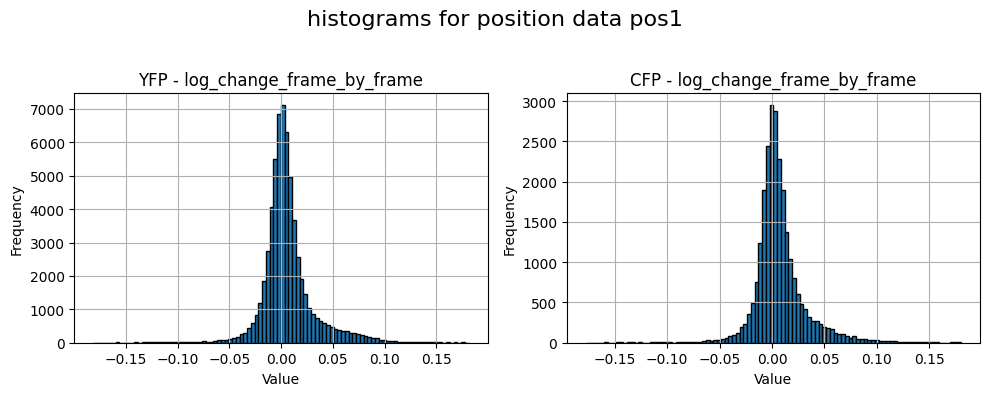

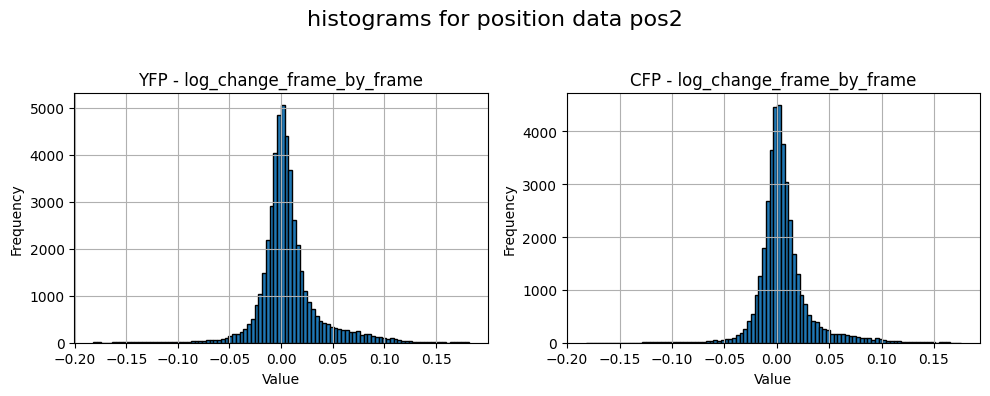

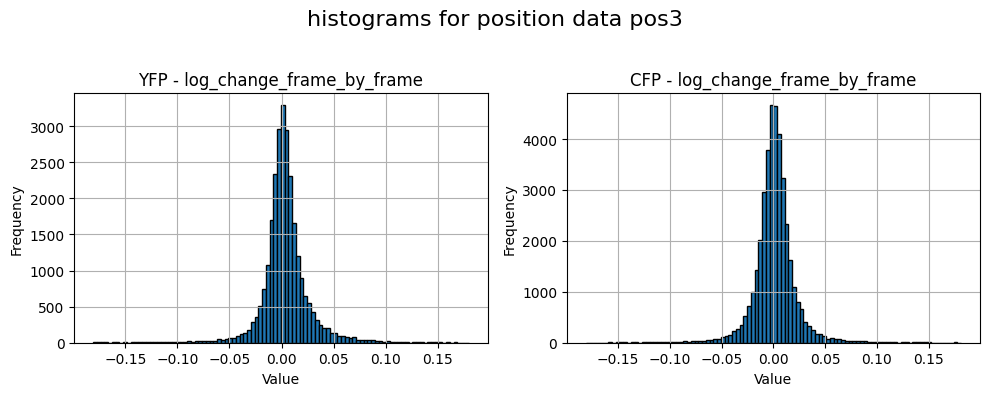

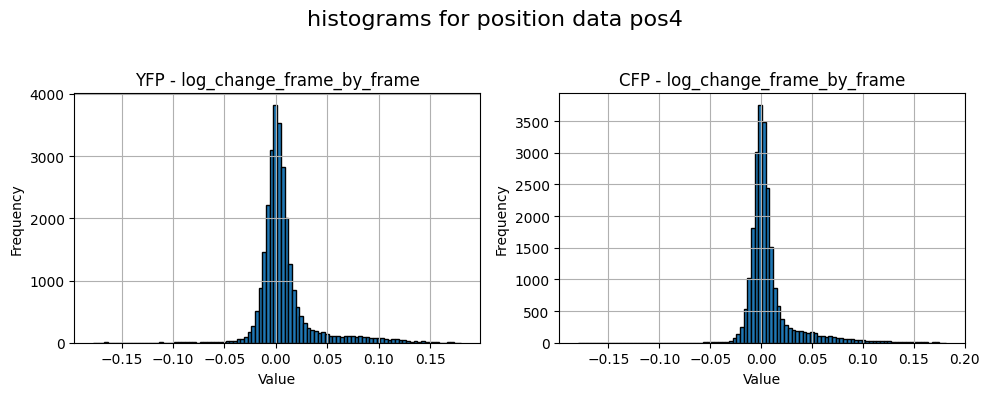

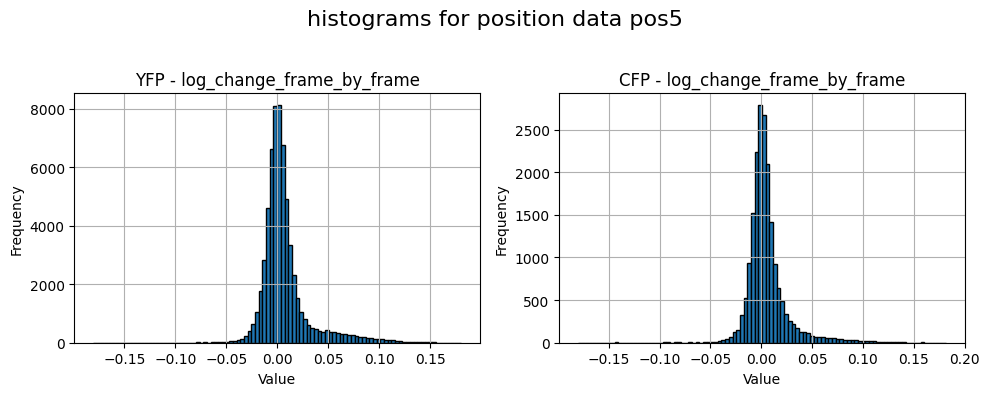

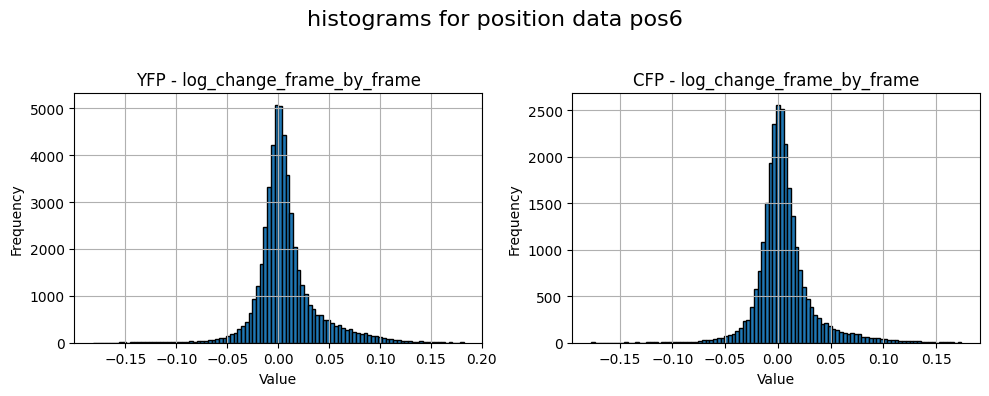

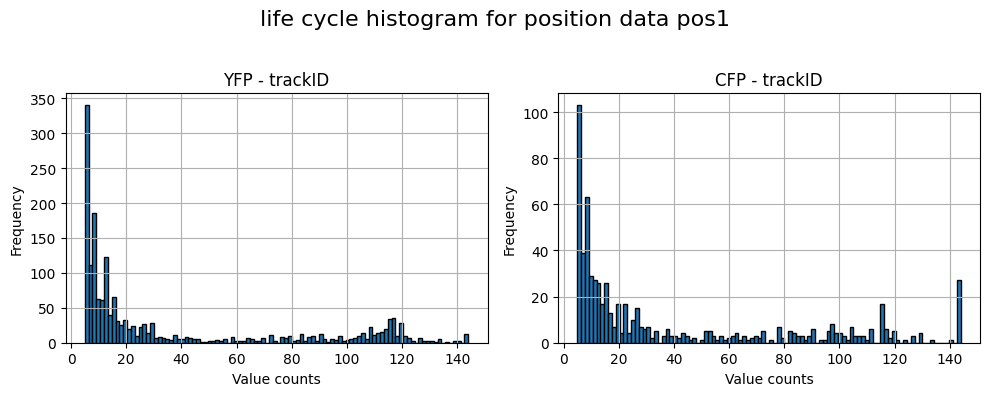

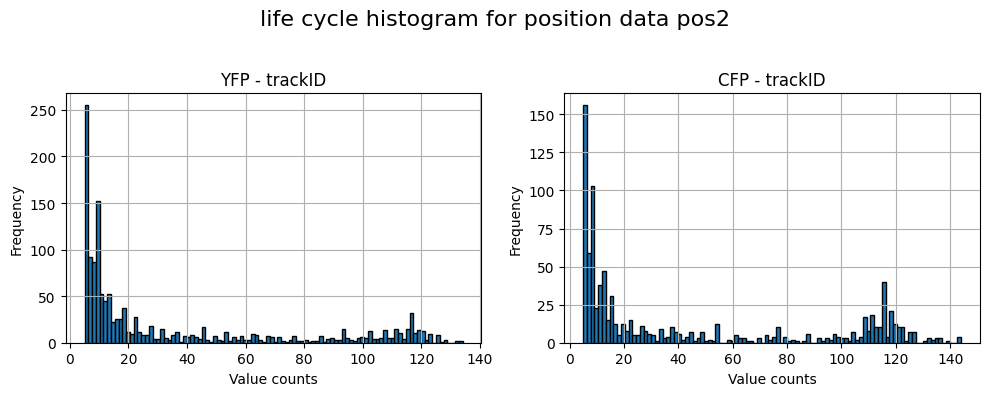

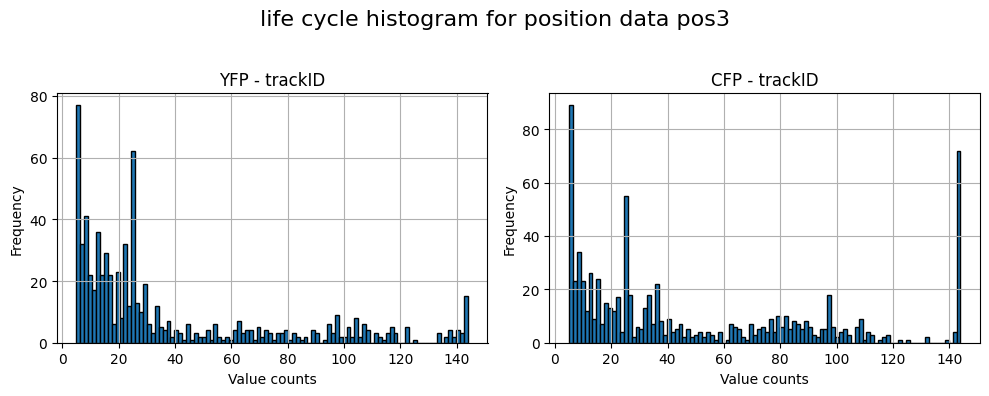

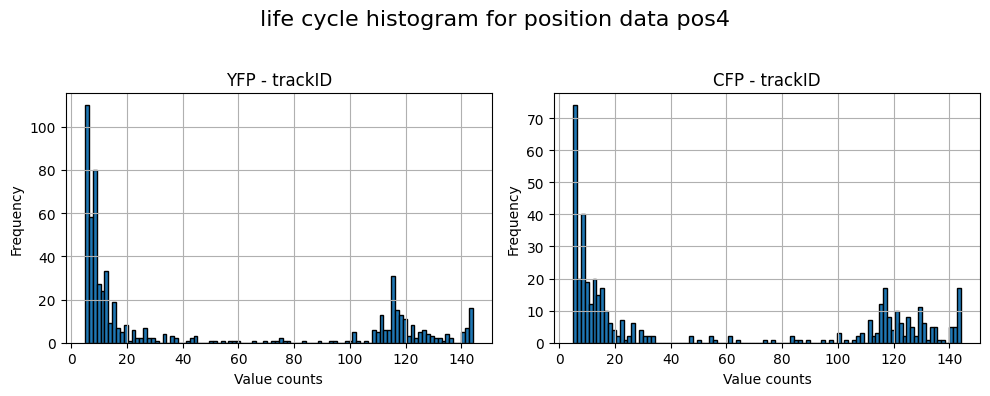

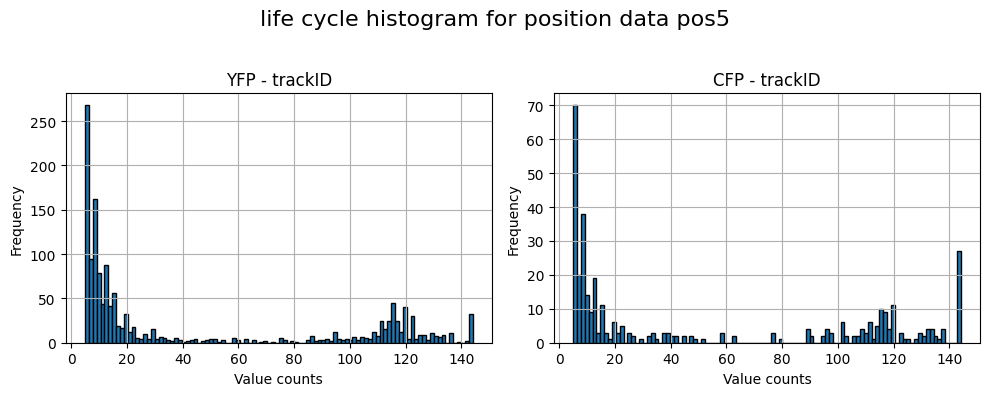

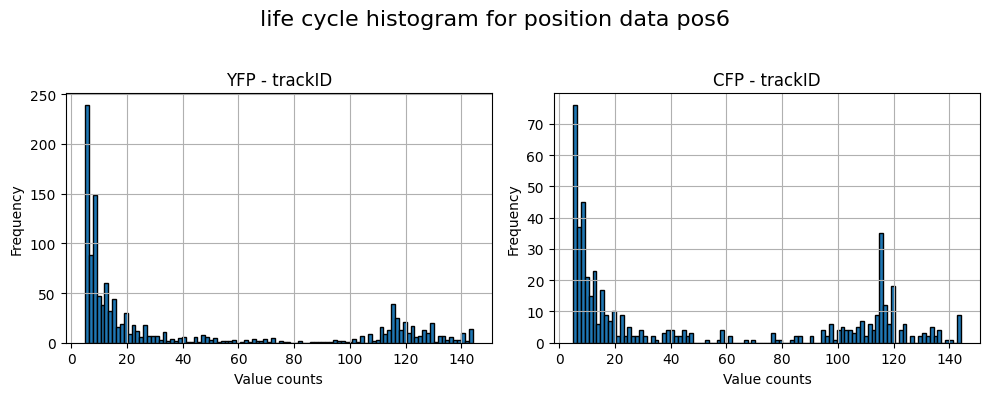

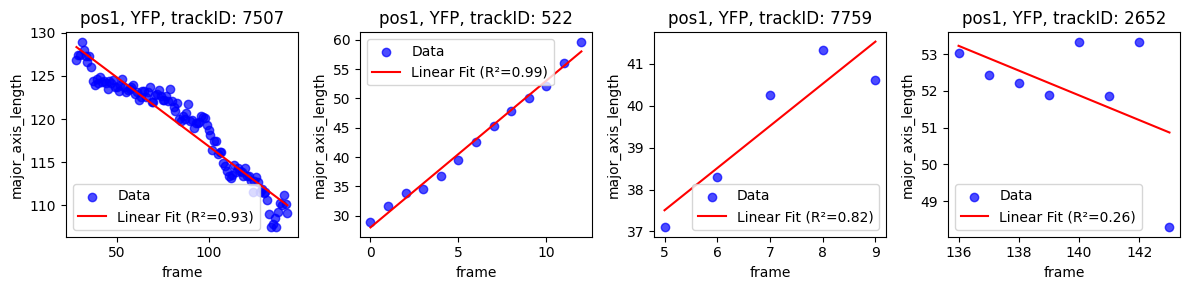

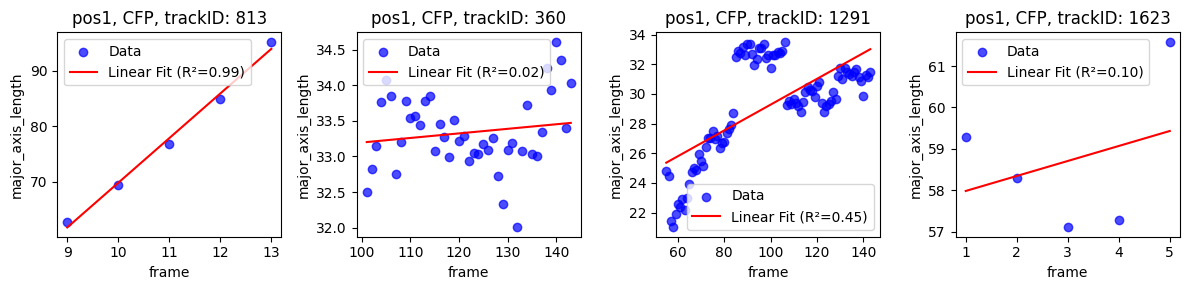

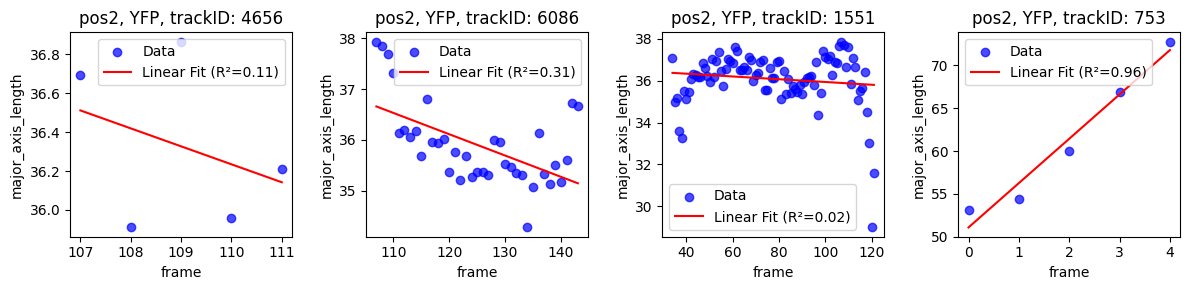

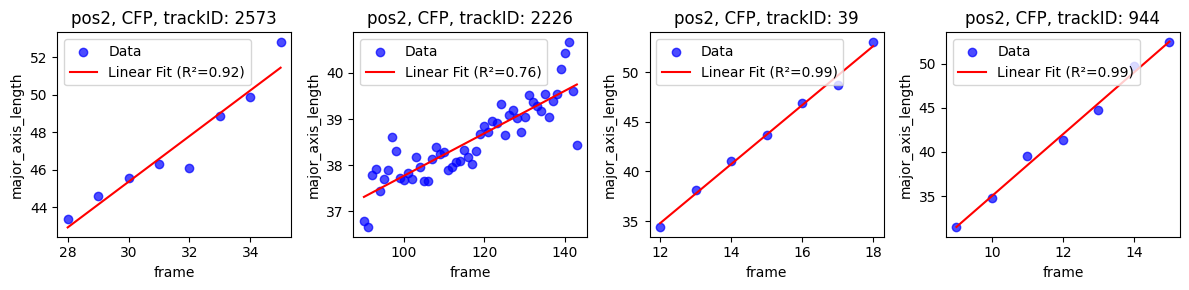

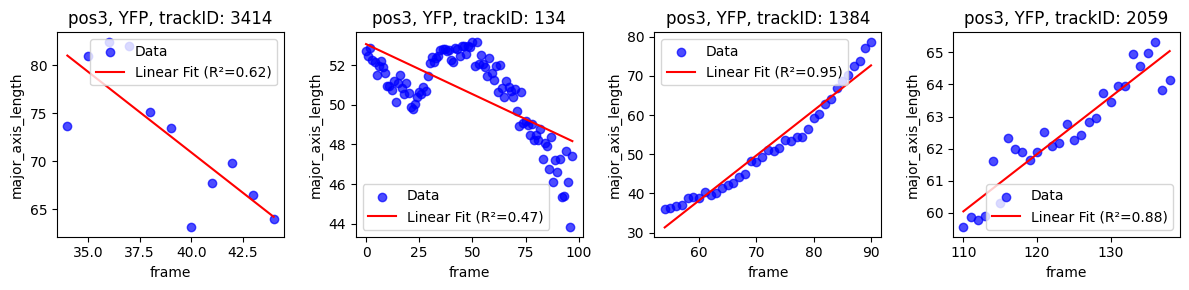

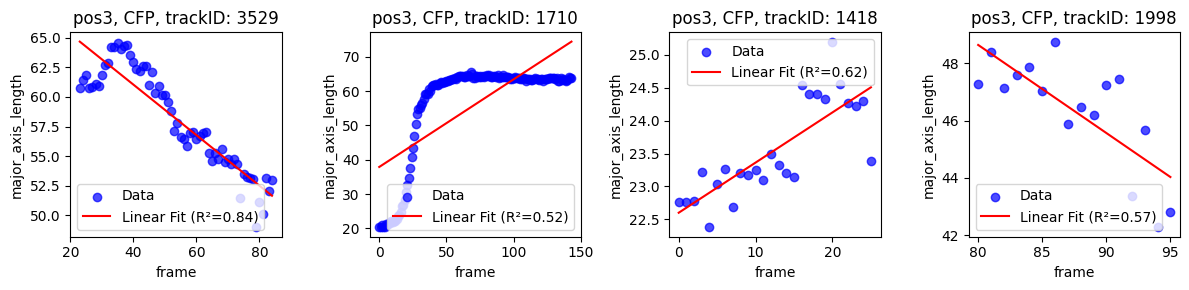

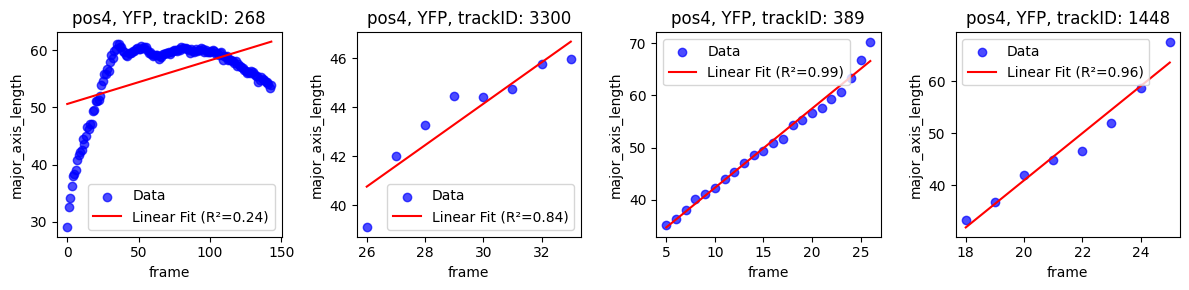

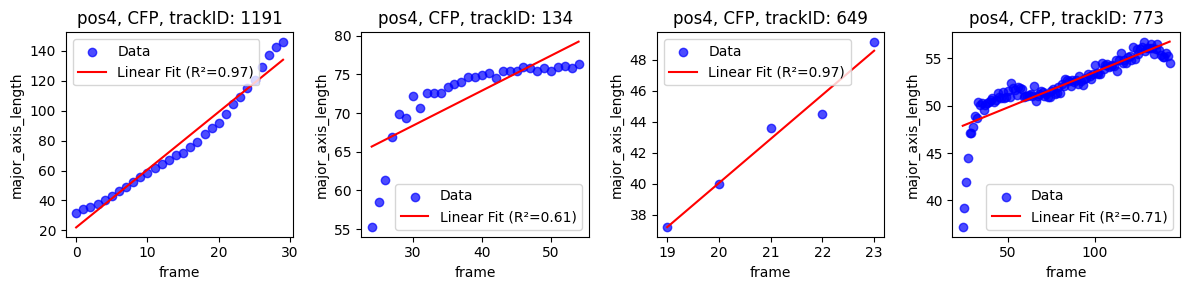

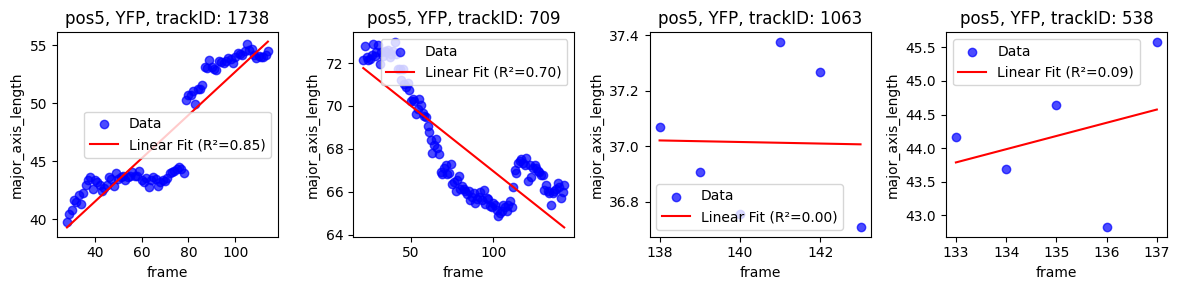

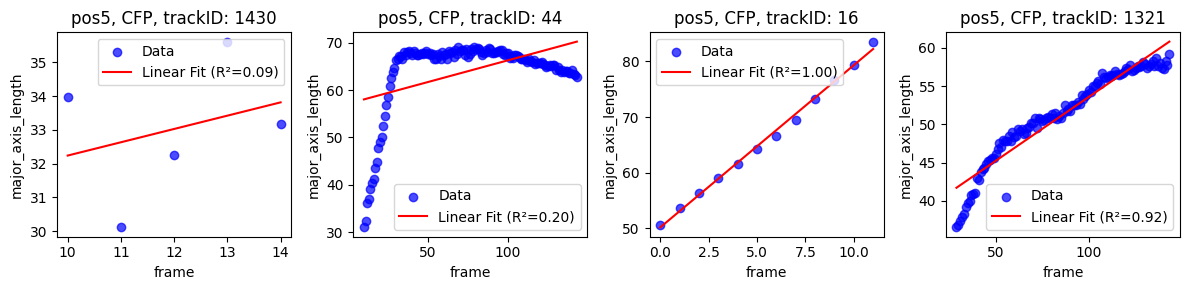

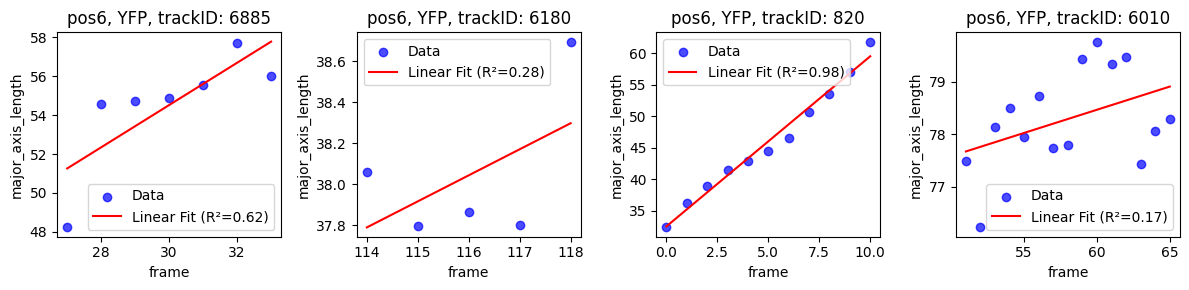

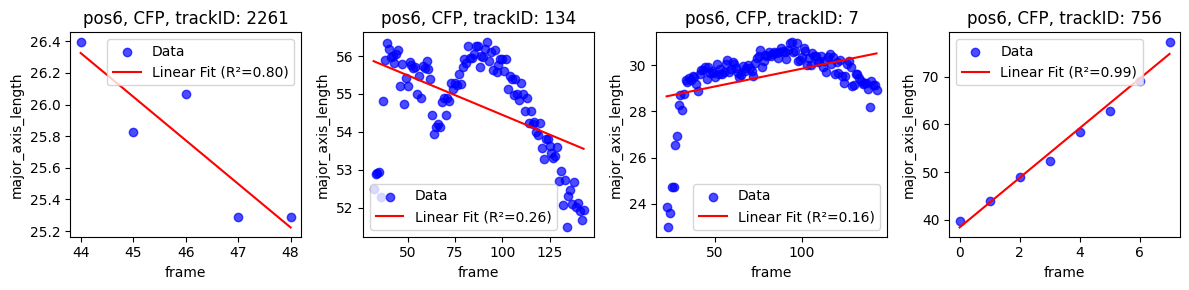

In [4]:
experiment.plot_qc_histograms(columns="log_change_frame_by_frame")  #histogram of the frame by frame log change
experiment.plot_life_cycle_histograms(columns="trackID")  #histogram of life cycle lengths of all trackIDs

n_samples = 4  #how many random cells to show per position / color channel combination?
experiment.plot_qc(value_column=size_column, 
                   id_column= id_column,
                   n_samples = n_samples)  #random QC plots

## Visualization of unfiltered data for comparison

we produce the same visualizations with the data we copied just before filtering.

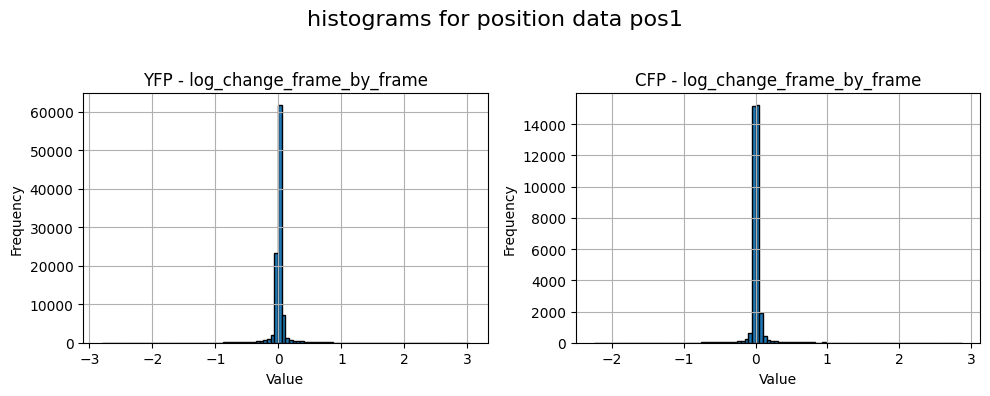

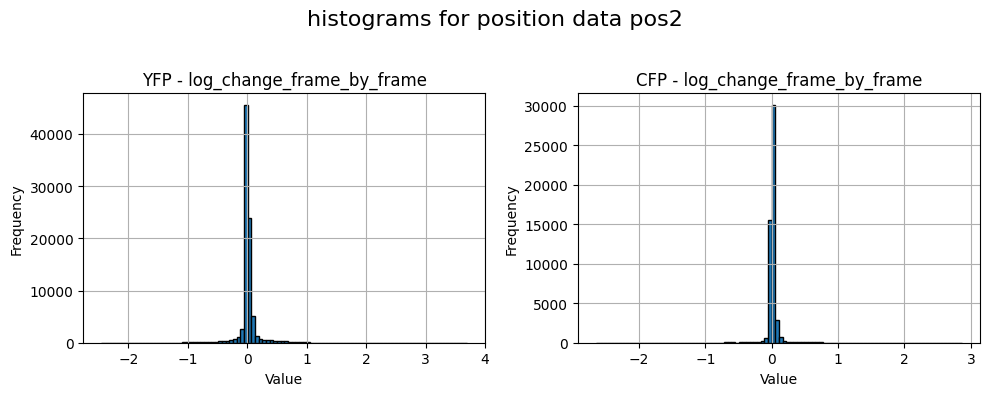

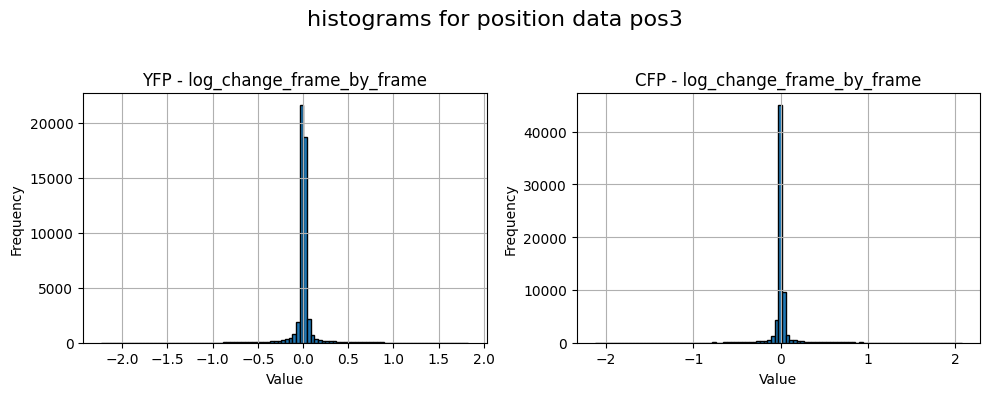

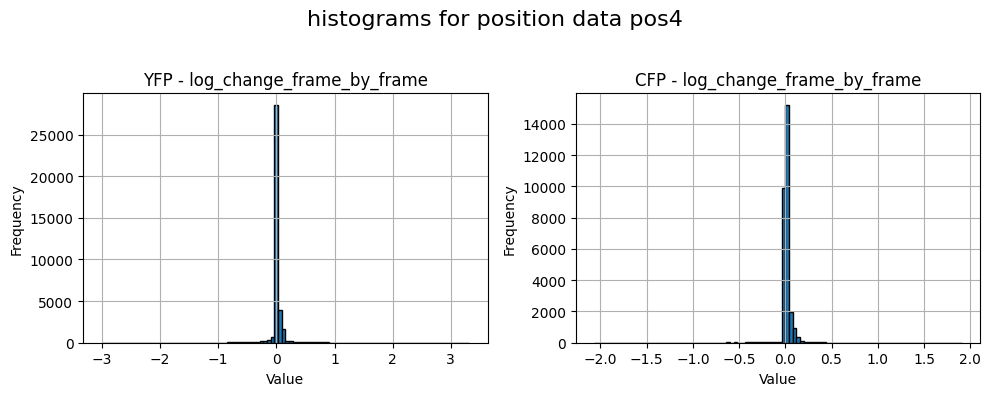

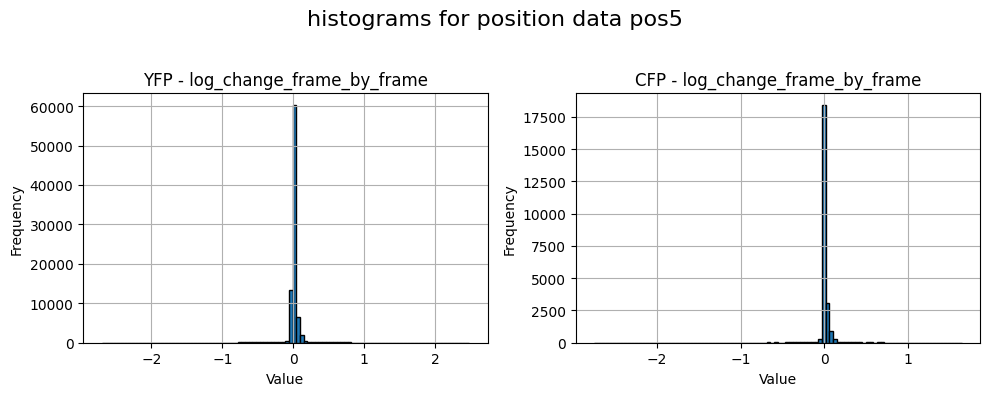

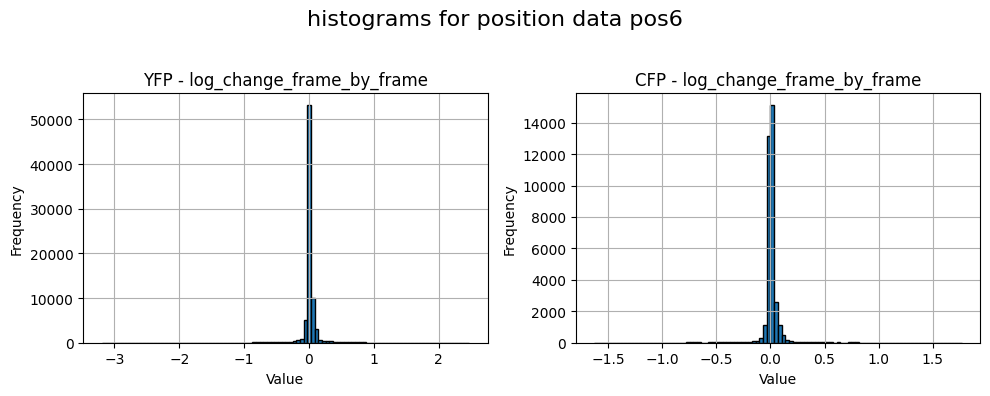

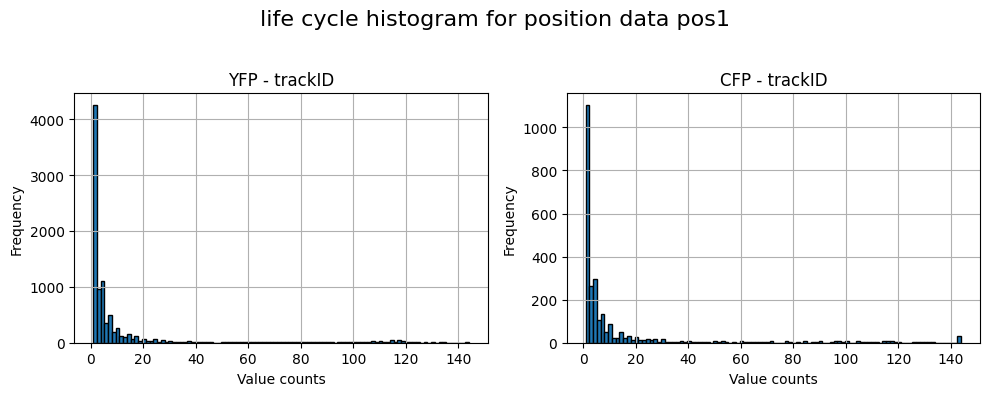

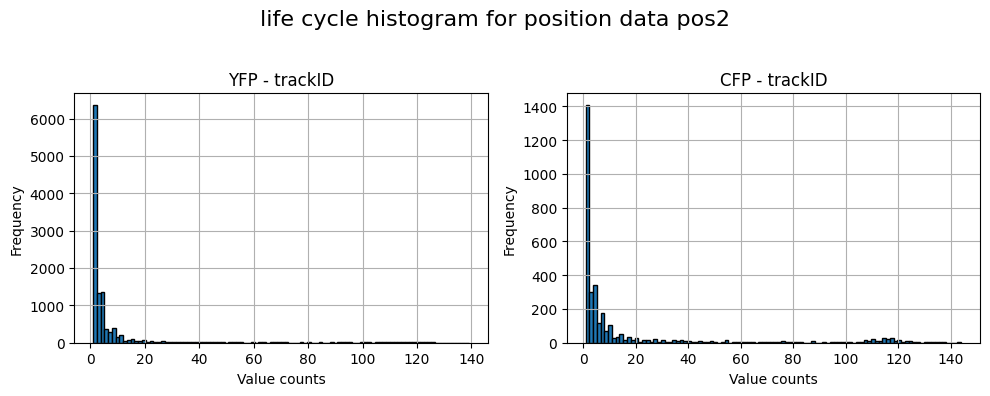

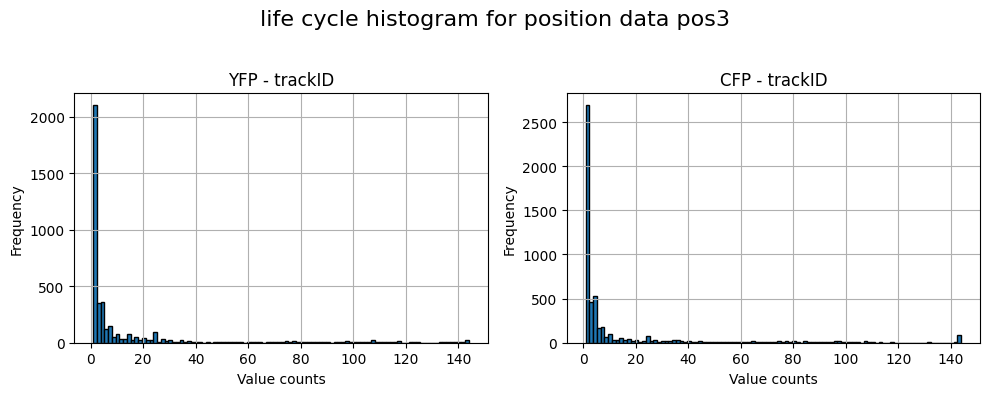

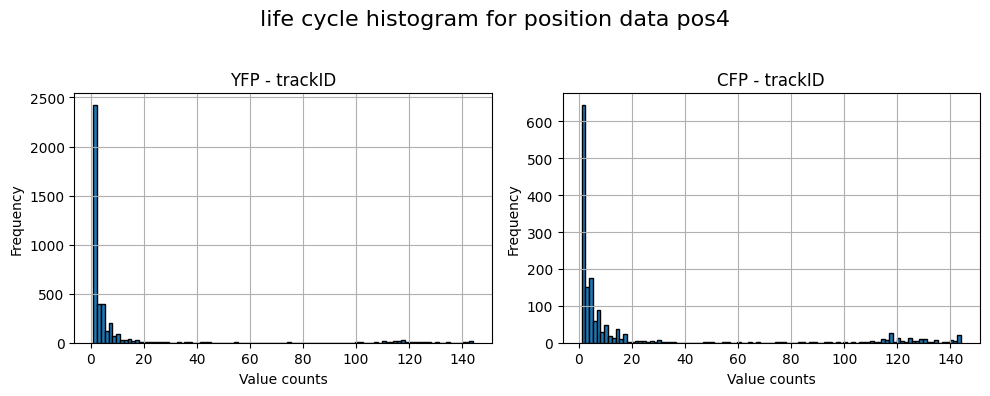

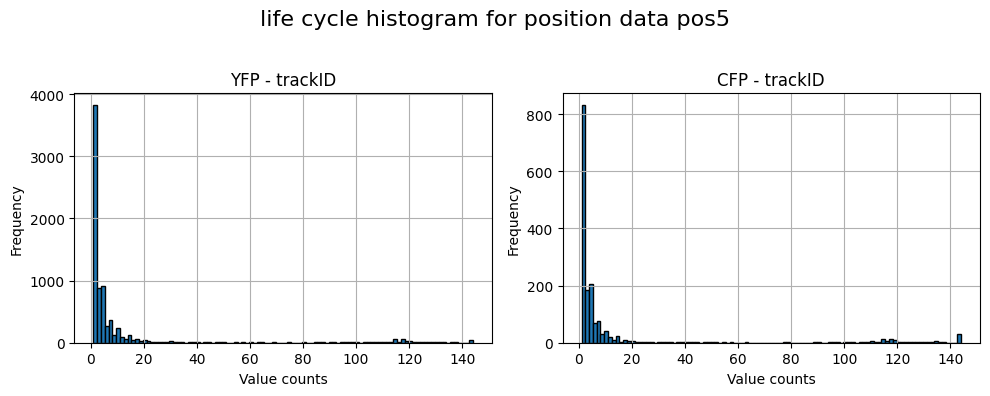

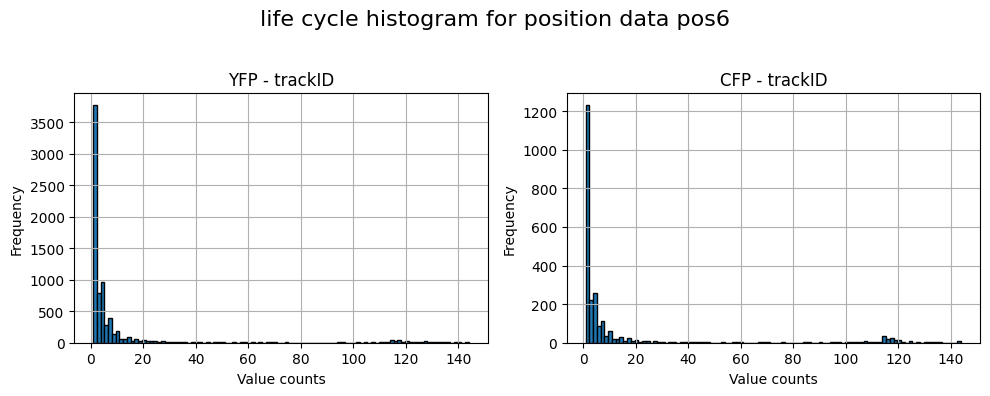

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


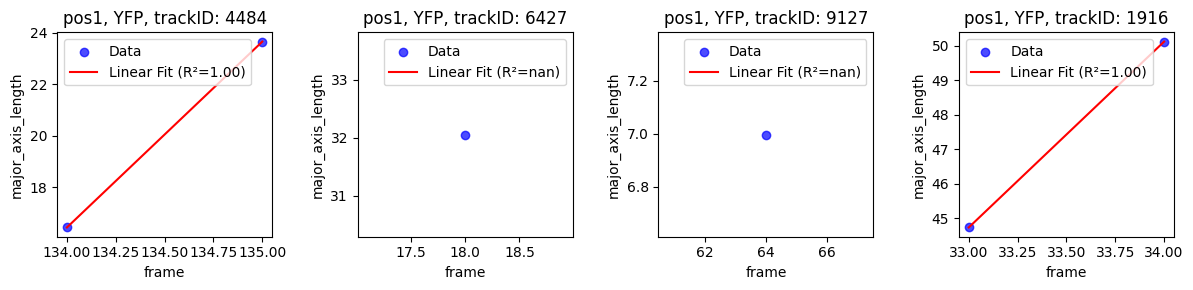

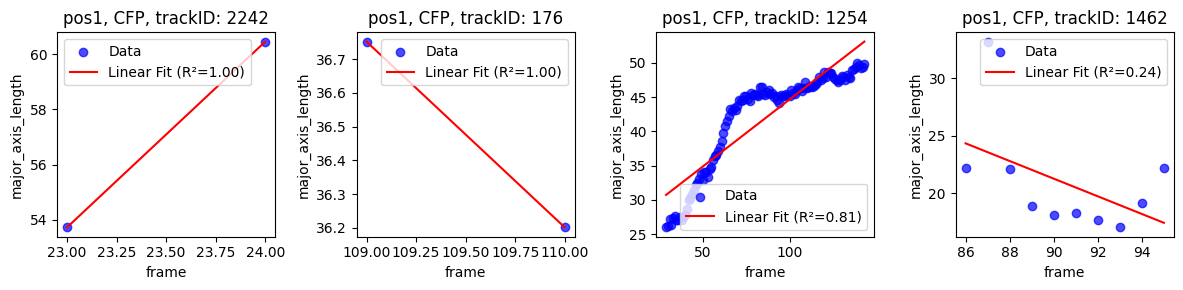

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


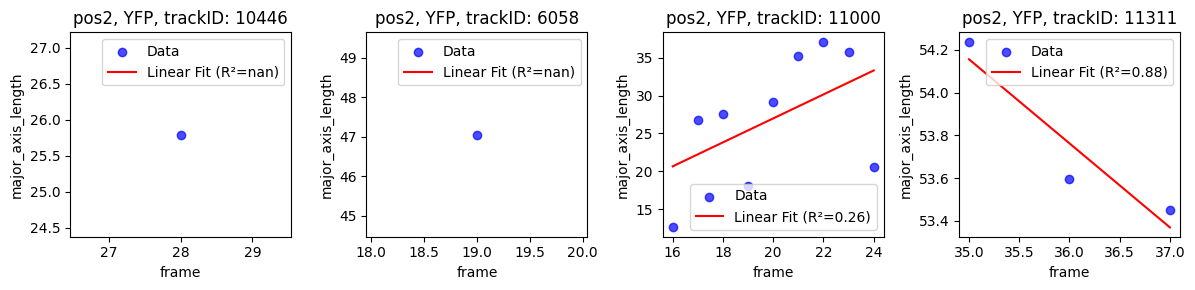

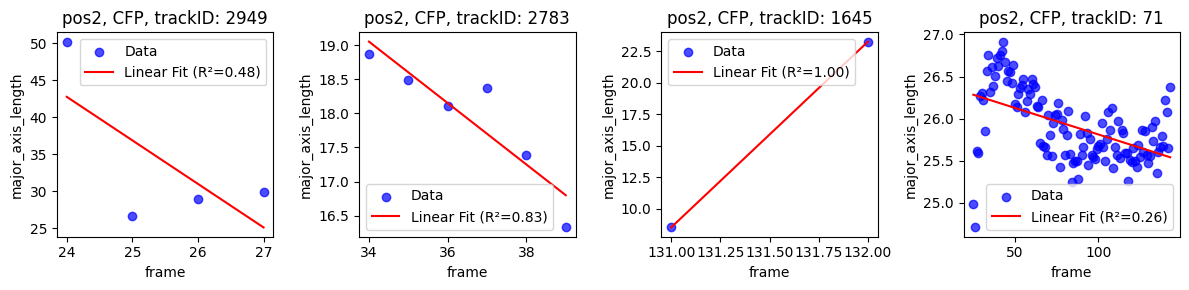

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


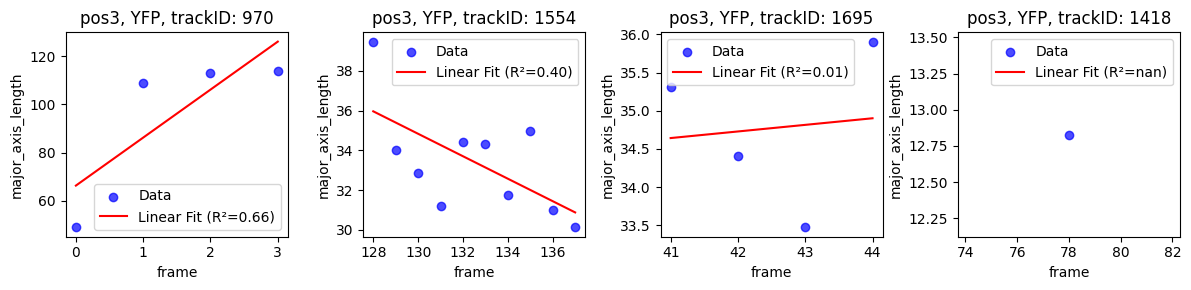

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


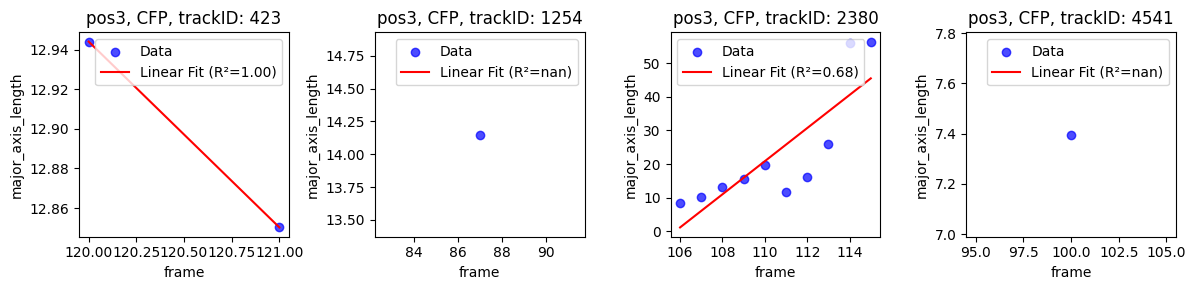

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


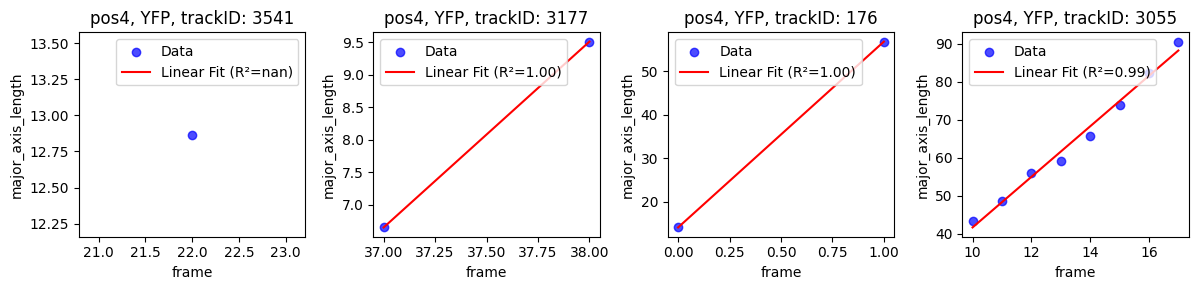

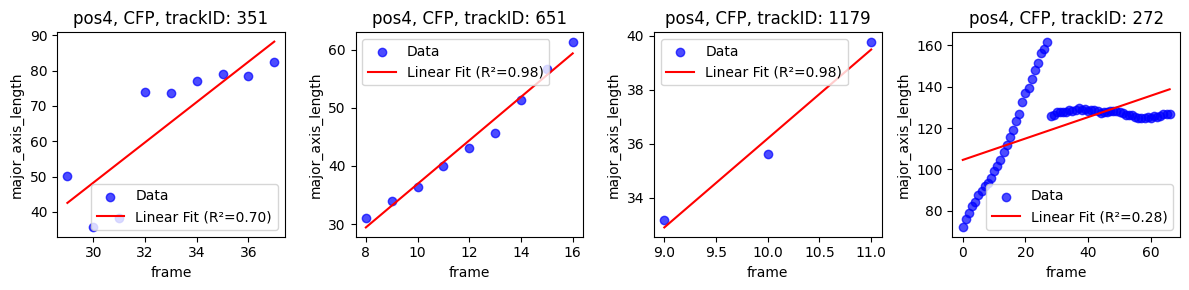

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


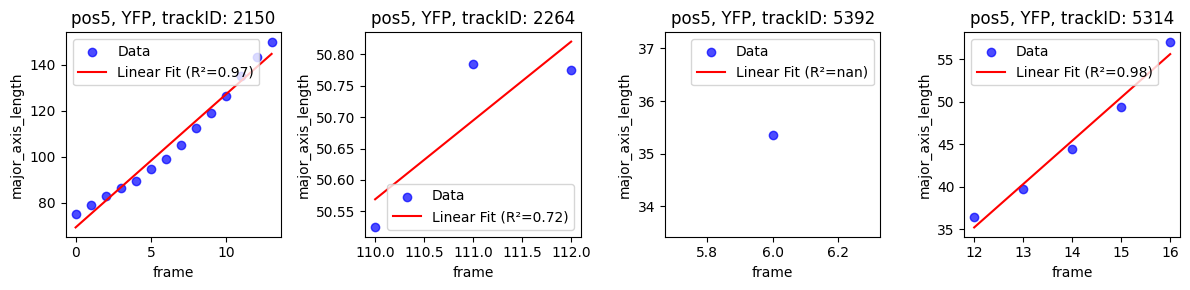

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


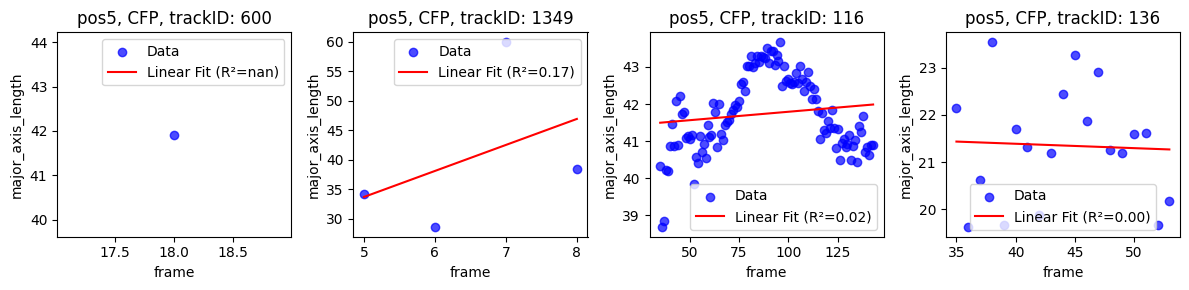

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


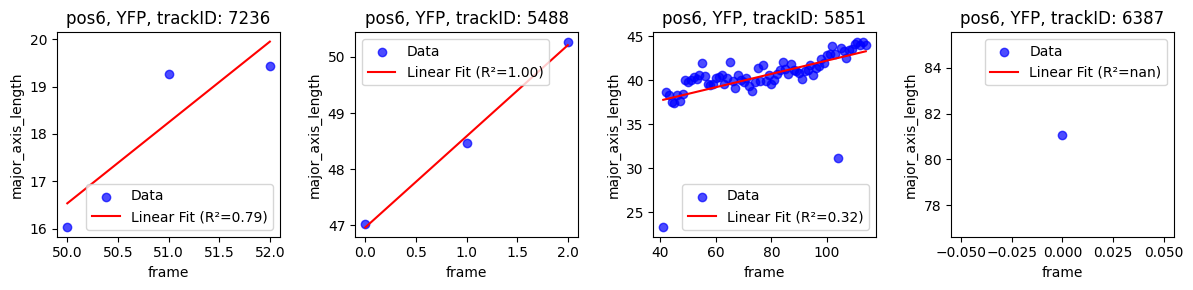

/opt/miniconda3/envs/midap-tools/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.


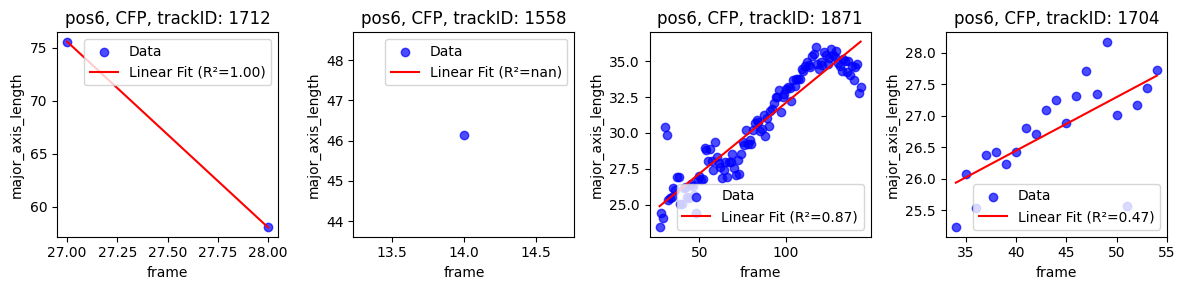

In [5]:
experiment_unfiltered.plot_qc_histograms(columns="log_change_frame_by_frame")  #histogram of the frame by frame log change
experiment_unfiltered.plot_life_cycle_histograms(columns="trackID")


n_samples = 4  #how many random cells to show per position / color channel combination?
experiment_unfiltered.plot_qc(value_column=size_column, 
                   id_column= id_column,
                   n_samples = n_samples)  #random QC plots